In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import scanpy.external as sce
import harmonypy as hm
import numpy as np

In [2]:
adata_85a = sc.read_h5ad("/mnt/home/gokulg/data/Qiu_E8.5a.h5ad")
adata_85b = sc.read_h5ad("/mnt/home/gokulg/data/Qiu_E8.5b.h5ad")

In [3]:
hvgs = pd.read_csv("/mnt/home/gokulg/data/embryos/hvg_v5.csv", header=None)[0].tolist()
conversion = pd.read_csv("/mnt/home/gokulg/data/mm39_annotations.csv", header=0)
gene_symbols = pd.read_csv("/mnt/home/gokulg/data/gene_symbols.tsv", sep='\t', header=0)

In [4]:
conversion_dict = {}

# for i, row in conversion.iterrows():
#     conversion_dict[row['gene_ids']] = row['gene_name']
#     conversion_dict[row['gene_name']] = row['gene_ids']
#     conversion_dict[row['gene_ids'].split('.')[0]] = row['gene_name']

for i, row in gene_symbols.iterrows():
    conversion_dict[row['Gene stable ID']] = row['MGI symbol']
    conversion_dict[row['MGI symbol']] = row['Gene stable ID']
    conversion_dict[row['Gene stable ID'].split('.')[0]] = row['MGI symbol']

for adata in [adata_85a, adata_85b]:
    adata.var_names = adata.var['features'].tolist()
    adata.var_names = [conversion_dict.get(v, v) for v in adata.var_names]
    adata.var_names_make_unique()

In [10]:
var_names_in_common = set(adata_85a.var_names).intersection(set(adata_85b.var_names))
print(f"Number of genes in common: {len(var_names_in_common)}")

adata_85a_hvg = adata_85a[:, [h for h in hvgs if h in var_names_in_common]].copy()
adata_85b_hvg = adata_85b[:, [h for h in hvgs if h in var_names_in_common]].copy()

Number of genes in common: 24343


In [8]:
adata_85a

AnnData object with n_obs × n_vars = 16909 × 29452
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'day', 'group', 'cell_state', 'cell_type'
    var: '_index', 'features'

In [11]:
combined = ad.concat([adata_85a_hvg, adata_85b_hvg], axis='obs', join='outer', 
                     label='dataset', keys=['qiu2022_a', 'qiu2022_b'])

In [12]:
# preprocess and pca combined
sc.pp.normalize_total(combined, target_sum=1e4)
sc.pp.log1p(combined)
# sc.pp.scale(combined, max_value=10)
# sc.tl.pca(combined, svd_solver='arpack')

In [13]:
sc.tl.rank_genes_groups(combined, groupby='dataset', method='wilcoxon')

top_genes_df = sc.get.rank_genes_groups_df(combined, group=None, key='rank_genes_groups')

k = 1000
top_k = top_genes_df.groupby('group').head(k)

gene_subset = [x for x in combined.var_names if x not in top_k['names'].values]
combined = combined[:, gene_subset].copy()


/tmp/ipykernel_11404/2847062697.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_k = top_genes_df.groupby('group').head(k)


In [14]:
sc.tl.pca(combined)

In [15]:
pcs = combined.obsm['X_pca'] # (n_cells, n_pcs)
harmony_out = hm.run_harmony(pcs, combined.obs, "dataset")
combined.obsm['X_pca_harmony'] = harmony_out.Z_corr

2026-03-20 12:01:26,155 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-03-20 12:01:26,156 - harmonypy - INFO -   Parameters:
2026-03-20 12:01:26,157 - harmonypy - INFO -     max_iter_harmony: 10
2026-03-20 12:01:26,157 - harmonypy - INFO -     max_iter_kmeans: 20
2026-03-20 12:01:26,158 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-03-20 12:01:26,158 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-03-20 12:01:26,159 - harmonypy - INFO -     nclust: 100
2026-03-20 12:01:26,159 - harmonypy - INFO -     block_size: 0.05
2026-03-20 12:01:26,160 - harmonypy - INFO -     lamb: [1. 1.]
2026-03-20 12:01:26,160 - harmonypy - INFO -     theta: [2. 2.]
2026-03-20 12:01:26,161 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-03-20 12:01:26,161 - harmonypy - INFO -     verbose: True
2026-03-20 12:01:26,162 - harmonypy - INFO -     random_state: 0
2026-03-20 12:01:26,162 - harmonypy - INFO -   Data: 50 PCs × 171222 cells
2026-03-20 12:01:26,163 - harmonypy - INF

In [16]:
# umap
sc.pp.neighbors(combined, use_rep='X_pca_harmony')
sc.tl.umap(combined)

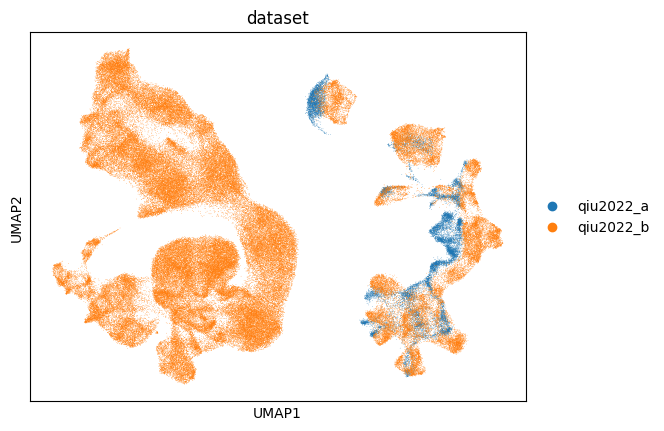

In [17]:
sc.pl.umap(combined, color=['dataset'], wspace=0.4)

In [18]:
combined.X.data

array([2.76512043, 2.49821062, 1.55185924, ..., 2.77118359, 3.82717513,
       3.93035617], shape=(151484404,))